# Gender Saliency & CLIP Evaluation Notebook

This notebook integrates:
- **CLIP Zero-Shot Gender Classification** (`clip_gender_eval.py`)
- **Gender Saliency Heatmaps** (`gender_saliency.py`)
- **VAE Latent Space Interpolation** (`compute_vae_interp_embeddings.py`)
- **Scribble Difference Visualization** (`scribble_diff.py`)
- **Target Distribution Plots** (`plot_target_distributions.py`)

---

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Configuration](#2-configuration)
3. [Load Models](#3-load-models)
4. [Load & Preview Scribbles](#4-load--preview-scribbles)
5. [Scribble Difference Heatmap](#5-scribble-difference-heatmap)
   - 5a. [Added / Omitted Pixel Visualization](#5a-added--omitted-pixel-visualization)
6. [CLIP Zero-Shot Gender Classification](#6-clip-zero-shot-gender-classification)
   - 6a. [Generate & Classify Photos from Each Scribble](#6a-generate--classify-photos-from-each-scribble)
   - 6b. [Classification Grid Visualisation](#6b-classification-grid-visualisation)
   - 6c. [Confidence Boxplot](#6c-confidence-boxplot)
7. [Gender Saliency Heatmap](#7-gender-saliency-heatmap)
   - 7a. [Saliency Lines & Correlation Plot](#7a-saliency-lines--correlation-plot)
   - 7b. [Save Results](#7b-save-results)

---
## 1. Setup & Imports

In [1]:
import os, sys

if 'google.colab' in str(get_ipython()):
    import getpass
    !pip install -q diffusers transformers accelerate controlnet_aux scikit-learn peft scipy
    from huggingface_hub import login
    from google.colab import userdata
    login(token=userdata.get('HF'))
    token = userdata.get('GITHUB') or getpass.getpass('GitHub token: ')
    repo = 'conditional-matching-paper'
    if not os.path.exists(repo):
        !git clone https://{token}@github.com/orineo1/conditional-matching-paper.git
    !cd {repo} && git checkout main && git pull
    for p in [f'/content/{repo}', f'/content/{repo}/SD_cond_SD_controlnet']:
        if p not in sys.path:
            sys.path.insert(0, p)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 7.7 MB/s eta 0:00:00
Cloning into 'conditional-matching-paper'...
remote: Enumerating objects: 7204, done.
remote: Counting objects: 100% (218/218), done.
remote: Compressing objects: 100% (139/139), done.
remote: Total 7204 (delta 165), reused 102 (delta 79), pack-reused 6986 (from 2)
Receiving objects: 100% (7204/7204), 1.41 GiB | 55.19 MiB/s, done.
Resolving deltas: 100% (2430/2430), done.
Updating files: 100% (109/109), done.
Already on 'main'
Your branch is up to date with 'origin/main'.
Already up to date.


In [2]:
import math
import pickle

import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import ImageGrid, make_axes_locatable
from PIL import Image
from pathlib import Path
from scipy.ndimage import gaussian_filter
from scipy.stats import spearmanr, pearsonr
from tqdm.notebook import tqdm
from transformers import CLIPModel, CLIPProcessor

from clip_utils import load_clip_model, encode_images_clip
from models import load_models, freeze_module

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


---
## 2. Configuration

In [3]:
REPO_ROOT       = Path('/content/conditional-matching-paper')
EXP_DIR         = REPO_ROOT / 'SD_cond_SD_controlnet' / 'experiments' / 'BalancedTarget'
SCRIBBLE_SOURCE = EXP_DIR / 'scribble_source.png'
SCRIBBLE_MLGDD  = EXP_DIR / 'scribble_mlgdd.png'

# ── Saliency (mirrors gender_saliency.py defaults) ────────────────────────────
N_SEEDS          = 20
SIGMA            = 2.5
VARIATION_PROMPT = 'a superrealistic professional photograph of'
CONTROLNET_SCALE = 0.5

# ── CLIP classification (mirrors clip_gender_eval.py) ─────────────────────────
MALE_PROMPT   = 'a photo of a man'
FEMALE_PROMPT = 'a photo of a woman'
N_EVAL        = 20          # photos per scribble to classify
EVAL_PROMPT   = 'a superrealistic professional photograph of'

# ── Scribble difference: threshold to define a "changed" pixel ────────────────
DIFF_THRESHOLD = 0.1       # L2 diff below this → pixel is considered unchanged

# ── Figure layout ─────────────────────────────────────────────────────────────
H = 3.5   # uniform figure row height (inches)

print('Config loaded.')

Config loaded.


---
## 3. Load Models

In [4]:
print('Loading CLIP model...')
clip_model, clip_processor = load_clip_model(device)

print('Loading Sprinter (VAE + ControlNet + UNet)...')
_, sprinter = load_models(device)

# Freeze all weights — only forward passes + one backward for saliency needed
sprinter.unet.enable_gradient_checkpointing()
sprinter.controlnet.enable_gradient_checkpointing()
freeze_module(sprinter.unet)
freeze_module(sprinter.controlnet)
freeze_module(sprinter.vae)

vae = sprinter.vae
vae_scaling_factor = vae.config.scaling_factor
print('All models loaded.')

Loading CLIP model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

All models loaded.


In [5]:
# Cast to float16 to avoid dtype mismatch during generation
sprinter.unet       = sprinter.unet.half()
sprinter.controlnet = sprinter.controlnet.half()
sprinter.vae        = sprinter.vae.half()
vae = sprinter.vae   # re-assign after reassignment above
print('Models cast to float16.')

Models cast to float16.


---
## 4. Load & Preview Scribbles

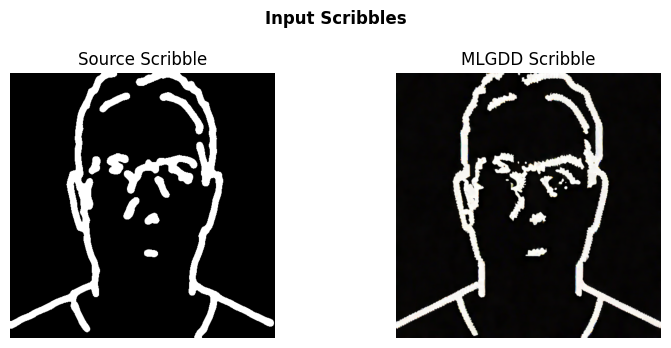

In [6]:
def load_scribble(path: Path, size: int = 512) -> tuple[np.ndarray, Image.Image]:
    """Load a scribble PNG, resize, return (np float32 HWC in [0,1], PIL Image)."""
    pil = Image.open(path).convert('RGB').resize((size, size))
    arr = np.array(pil).astype(np.float32) / 255.0
    return arr, pil


src_np,  src_pil  = load_scribble(SCRIBBLE_SOURCE)
mlgd_np, mlgd_pil = load_scribble(SCRIBBLE_MLGDD)

fig, axes = plt.subplots(1, 2, figsize=(8, H))
axes[0].imshow(src_np);  axes[0].set_title('Source Scribble');    axes[0].axis('off')
axes[1].imshow(mlgd_np); axes[1].set_title('MLGDD Scribble');     axes[1].axis('off')
fig.suptitle('Input Scribbles', fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# ── Count line pixels on the source scribble ──────────────────────────────────
line_mask     = src_np.mean(axis=2) > 0.05
n_line_pixels = line_mask.sum()
print(f'Line pixels (non-background, threshold > 0.05): {n_line_pixels:,}')
print(f'Background pixels                              : {(~line_mask).sum():,}')
print(f'Total pixels                                   : {line_mask.size:,}')

# ── Tune threshold if needed to match paper's n=33,828 ───────────────────────
for t in [0.02, 0.05, 0.08, 0.10, 0.15, 0.20]:
    n = (src_np.mean(axis=2) > t).sum()
    marker = '  ← paper n=33,828' if abs(n - 33828) < 500 else ''
    print(f'  threshold={t:.2f}  →  {n:,} line pixels{marker}')

Line pixels (non-background, threshold > 0.05): 33,828
Background pixels                              : 228,316
Total pixels                                   : 262,144
  threshold=0.02  →  33,828 line pixels  ← paper n=33,828
  threshold=0.05  →  33,828 line pixels  ← paper n=33,828
  threshold=0.08  →  33,828 line pixels  ← paper n=33,828
  threshold=0.10  →  33,828 line pixels  ← paper n=33,828
  threshold=0.15  →  33,828 line pixels  ← paper n=33,828
  threshold=0.20  →  33,828 line pixels  ← paper n=33,828


---
## 5. Scribble Difference Heatmap

Per-pixel L2 difference between the MLGDD (optimised) and source scribbles, mirroring `scribble_diff.py`.

In [8]:
# Compute raw L2 difference and smoothed version
diff_raw    = np.linalg.norm(mlgd_np - src_np, axis=2)          # [512, 512]
diff_smooth = gaussian_filter(diff_raw, sigma=SIGMA)

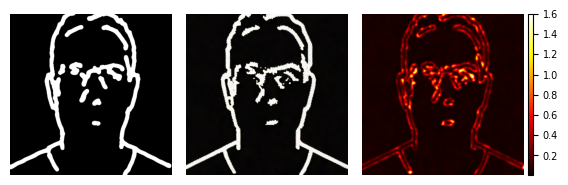

Max diff: 1.6001  |  Mean diff: 0.0903


In [9]:
def plot_scribble_comparison(
    src_np: np.ndarray,
    mlgd_np: np.ndarray,
    diff_smooth: np.ndarray,
) -> None:
    """Three-panel: Source | Optimized | Smoothed L2 difference heatmap."""
    fig = plt.figure(figsize=(6.75, 2.2))
    grid = ImageGrid(
        fig, 111,
        nrows_ncols=(1, 3),
        axes_pad=0.15,
        cbar_location='right',
        cbar_mode='single',
        cbar_size='3%',
        cbar_pad=0.05,
    )
    grid[0].imshow(src_np);  grid[0].axis('off')
    grid[1].imshow(mlgd_np); grid[1].axis('off')
    im = grid[2].imshow(diff_smooth, cmap='hot')
    grid[2].axis('off')
    cb = grid.cbar_axes[0].colorbar(im)
    cb.ax.tick_params(labelsize=7)
    plt.savefig('scribble_comparison.png', dpi=600, bbox_inches='tight')
    plt.show()
    print(f'Max diff: {diff_smooth.max():.4f}  |  Mean diff: {diff_smooth.mean():.4f}')


plot_scribble_comparison(src_np, mlgd_np, diff_smooth)

### 5a. Added / Omitted Pixel Visualization

Shows **where the MLGDD optimiser added pixels** (green) and **where it removed pixels** (red) relative to the source scribble. Pixels whose L2 change is below `DIFF_THRESHOLD` are treated as unchanged and masked out (shown as the original scribble in grey).

- **Green** → MLGDD is brighter than source (stroke added / thickened)
- **Red**   → MLGDD is darker than source (stroke removed / thinned)

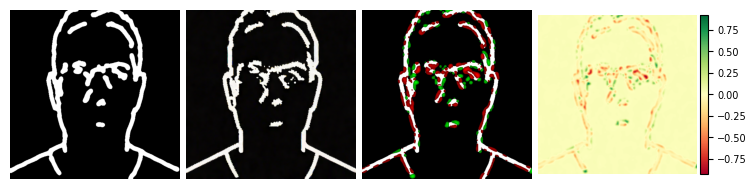

Unchanged : 239,252  (91.3%)
Added     : 7,378  (2.8%)
Removed   : 15,514  (5.9%)


In [10]:
def plot_added_omitted(
    src_np: np.ndarray,
    mlgd_np: np.ndarray,
    threshold: float = DIFF_THRESHOLD,
    sigma: float = SIGMA,
) -> None:
    signed_diff_raw    = (mlgd_np - src_np).mean(axis=2)
    signed_diff_smooth = gaussian_filter(signed_diff_raw, sigma=sigma)

    changed_mask = np.abs(signed_diff_smooth) >= threshold
    added_mask   = changed_mask & (signed_diff_smooth > 0)
    removed_mask = changed_mask & (signed_diff_smooth < 0)

    grey    = src_np.mean(axis=2, keepdims=True).repeat(3, axis=2)
    overlay = grey.copy()
    add_mag  = np.where(added_mask,    signed_diff_smooth,  0.0)
    rem_mag  = np.where(removed_mask, -signed_diff_smooth,  0.0)
    add_norm = add_mag / (add_mag.max() + 1e-8)
    rem_norm = rem_mag / (rem_mag.max() + 1e-8)
    overlay[added_mask,   0] = 0.0
    overlay[added_mask,   1] = 0.4 + 0.6 * add_norm[added_mask]
    overlay[added_mask,   2] = 0.0
    overlay[removed_mask, 0] = 0.4 + 0.6 * rem_norm[removed_mask]
    overlay[removed_mask, 1] = 0.0
    overlay[removed_mask, 2] = 0.0
    overlay = np.clip(overlay, 0.0, 1.0)

    vmax = np.abs(signed_diff_smooth[changed_mask]).max() if changed_mask.any() else 1.0

    fig, axes = plt.subplots(1, 4, figsize=(9, 2.2),
                             gridspec_kw={'wspace': 0.04})
    for ax in axes:
        ax.axis('off')

    axes[0].imshow(src_np)
    axes[1].imshow(mlgd_np)
    axes[2].imshow(overlay)
    im = axes[3].imshow(signed_diff_smooth, cmap='RdYlGn', vmin=-vmax, vmax=vmax)
    divider = make_axes_locatable(axes[3])
    cb = plt.colorbar(im, cax=divider.append_axes('right', size='5%', pad=0.03))
    cb.ax.tick_params(labelsize=7)

    plt.savefig('scribble_added_omitted.png', dpi=600, bbox_inches='tight')
    plt.show()

    total_px = changed_mask.size
    print(f'Unchanged : {total_px - changed_mask.sum():,}  ({100*(total_px-changed_mask.sum())/total_px:.1f}%)')
    print(f'Added     : {added_mask.sum():,}  ({100*added_mask.sum()/total_px:.1f}%)')
    print(f'Removed   : {removed_mask.sum():,}  ({100*removed_mask.sum()/total_px:.1f}%)')


plot_added_omitted(src_np, mlgd_np)

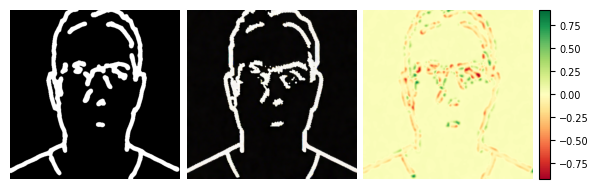

Unchanged : 239,252  (91.3%)
Added     : 7,378  (2.8%)
Removed   : 15,514  (5.9%)


In [12]:
def plot_scribble_full(
    src_np: np.ndarray,
    mlgd_np: np.ndarray,
    diff_smooth: np.ndarray,
    threshold: float = DIFF_THRESHOLD,
    sigma: float = SIGMA,
) -> None:
    signed_diff_smooth = gaussian_filter((mlgd_np - src_np).mean(axis=2), sigma=sigma)
    changed_mask = np.abs(signed_diff_smooth) >= threshold
    added_mask   = changed_mask & (signed_diff_smooth > 0)
    removed_mask = changed_mask & (signed_diff_smooth < 0)
    vmax_sd = np.abs(signed_diff_smooth[changed_mask]).max() if changed_mask.any() else 1.0

    fig, axes = plt.subplots(1, 3, figsize=(6.75, 2.2),
                             gridspec_kw={'wspace': 0.04, 'width_ratios': [1, 1, 1]})
    for ax in axes:
        ax.axis('off')

    axes[0].imshow(src_np)
    axes[1].imshow(mlgd_np)

    im_sd = axes[2].imshow(signed_diff_smooth, cmap='RdYlGn', vmin=-vmax_sd, vmax=vmax_sd)
    cbar_ax = fig.add_axes([
        axes[2].get_position().x1 + 0.01,
        axes[2].get_position().y0,
        0.015,
        axes[2].get_position().height,
    ])
    plt.colorbar(im_sd, cax=cbar_ax).ax.tick_params(labelsize=7)

    plt.savefig('scribble_full.png', dpi=600, bbox_inches='tight')
    plt.show()

    total_px = changed_mask.size
    print(f'Unchanged : {total_px - changed_mask.sum():,}  ({100*(total_px-changed_mask.sum())/total_px:.1f}%)')
    print(f'Added     : {added_mask.sum():,}  ({100*added_mask.sum()/total_px:.1f}%)')
    print(f'Removed   : {removed_mask.sum():,}  ({100*removed_mask.sum()/total_px:.1f}%)')


plot_scribble_full(src_np, mlgd_np, diff_smooth)

---
## 6. CLIP Zero-Shot Gender Classification

Mirrors `clip_gender_eval.py` — classifies a batch of PIL images as Male / Female.

In [10]:
# ── Precompute text embeddings once ──────────────────────────────────────────
_text_inputs = clip_processor(
    text=[MALE_PROMPT, FEMALE_PROMPT], return_tensors='pt', padding=True
).to(device)

with torch.no_grad():
    _text_out  = clip_model.get_text_features(**_text_inputs)
    _text_embs = _text_out if isinstance(_text_out, torch.Tensor) else _text_out.pooler_output
    _text_embs = _text_embs / _text_embs.norm(dim=-1, keepdim=True)  # [2, 768]


def classify_images_clip(
    pil_images: list[Image.Image],
    batch_size: int = 16,
) -> list[dict]:
    """Classify a list of PIL Images as Male / Female via CLIP zero-shot.

    Returns list of dicts: {gender, confidence, margin, male_prob}
    """
    results = []
    for i in range(0, len(pil_images), batch_size):
        batch  = pil_images[i : i + batch_size]
        inputs = clip_processor(images=batch, return_tensors='pt', padding=True).to(device)
        with torch.no_grad():
            img_out  = clip_model.get_image_features(**inputs)
            img_embs = img_out if isinstance(img_out, torch.Tensor) else img_out.pooler_output
            img_embs = img_embs / img_embs.norm(dim=-1, keepdim=True)
            sims  = img_embs @ _text_embs.T           # [B, 2]
            probs = torch.softmax(sims * 100, dim=1)  # temperature-scaled
        for prob, sim in zip(probs, sims):
            male_prob   = prob[0].item()
            female_prob = prob[1].item()
            gender      = 'Male' if male_prob > female_prob else 'Female'
            confidence  = max(male_prob, female_prob)
            margin      = sim[0].item() - sim[1].item()
            results.append(dict(
                gender=gender,
                confidence=round(confidence, 4),
                margin=round(margin, 4),
                male_prob=round(male_prob, 4),
            ))
    return results


def summarise_gender(results: list[dict]) -> dict:
    """Return n_male, n_female, balance metric L, mean confidence."""
    n_male    = sum(1 for r in results if r['gender'] == 'Male')
    n_female  = len(results) - n_male
    n_total   = len(results)
    L         = math.sqrt((n_male - n_total / 2) ** 2 + (n_female - n_total / 2) ** 2)
    conf_mean = sum(r['confidence'] for r in results) / max(n_total, 1)
    return dict(
        n_male=n_male, n_female=n_female,
        gender_L=round(L, 2),
        gender_conf_mean=round(conf_mean, 4),
    )


print('CLIP classifier ready.')

CLIP classifier ready.


### 6a. Generate & Classify Photos from Each Scribble

In [11]:
def generate_photos(
    scribble_pil: Image.Image,
    n: int = N_EVAL,
    prompt: str = EVAL_PROMPT,
    controlnet_scale: float = CONTROLNET_SCALE,
    seed_offset: int = 0,
) -> list[Image.Image]:
    """Run sprinter n times, returning PIL images."""
    photos = []
    for i in tqdm(range(n), desc='Generating photos'):
        generator = torch.Generator(device=device).manual_seed(i + seed_offset)
        with torch.no_grad():
            out = sprinter(
                prompt=[prompt],
                image=scribble_pil.convert('RGB'),
                num_inference_steps=2,
                guidance_scale=0.0,
                controlnet_conditioning_scale=controlnet_scale,
                generator=generator,
                output_type='latent',
            )
        latents = out.images  # [1, 4, H, W]
        with torch.no_grad():
            decoded = vae.float().decode(
                (latents.float() / vae_scaling_factor)
            ).sample
        pixels = ((decoded[0].float() + 1.0) / 2.0).clamp(0.0, 1.0)  # [3, H, W]
        img_np = (pixels.permute(1, 2, 0).cpu().numpy() * 255).round().astype(np.uint8)
        photos.append(Image.fromarray(img_np))
        vae.half()  # cast back after each decode
    return photos


print('Generating photos from SOURCE scribble...')
photos_source  = generate_photos(src_pil,  n=N_EVAL, seed_offset=0)
results_source = classify_images_clip(photos_source)
summary_source = summarise_gender(results_source)
print('Source  →', summary_source)

print('Generating photos from MLGDD scribble...')
photos_mlgdd  = generate_photos(mlgd_pil, n=N_EVAL, seed_offset=0)
results_mlgdd = classify_images_clip(photos_mlgdd)
summary_mlgdd = summarise_gender(results_mlgdd)
print('MLGDD   →', summary_mlgdd)

Generating photos from SOURCE scribble...


Generating photos:   0%|          | 0/20 [00:00<?, ?it/s]

Source  → {'n_male': 20, 'n_female': 0, 'gender_L': 14.14, 'gender_conf_mean': 0.9921}
Generating photos from MLGDD scribble...


Generating photos:   0%|          | 0/20 [00:00<?, ?it/s]

MLGDD   → {'n_male': 10, 'n_female': 10, 'gender_L': 0.0, 'gender_conf_mean': 0.9821}


### 6b. Classification Grid Visualisation

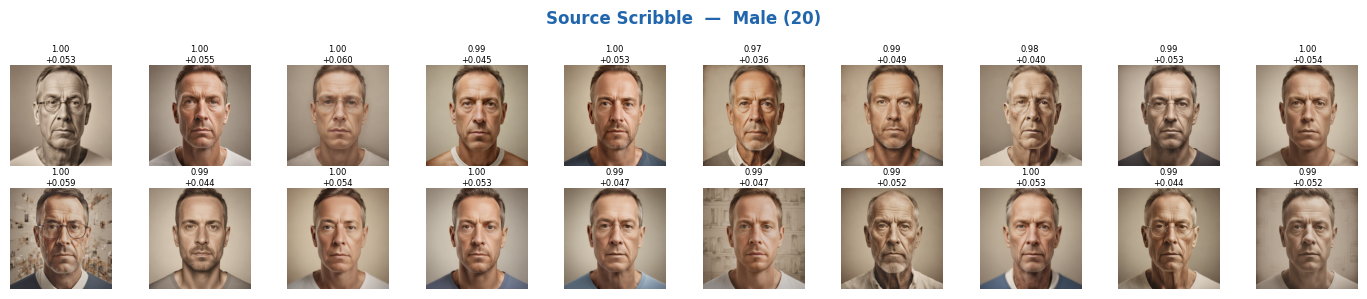

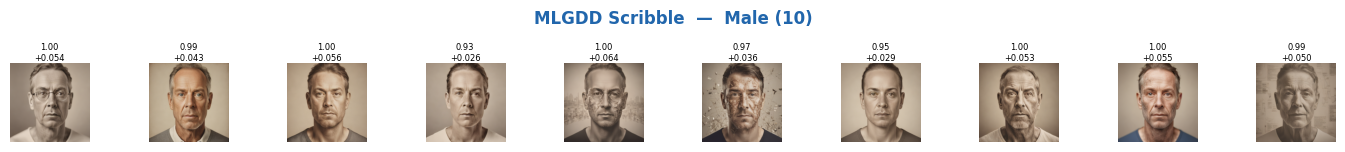

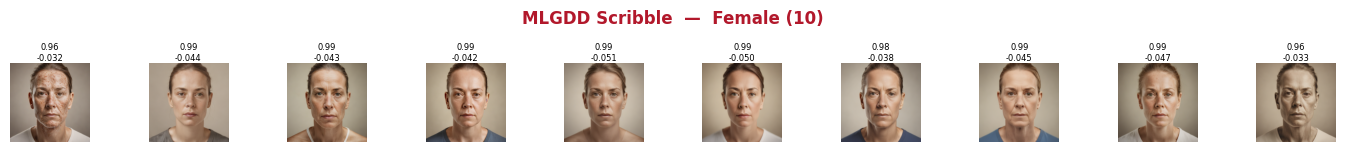

In [12]:
def plot_gender_grid(
    photos: list[Image.Image],
    results: list[dict],
    title: str = '',
    cols: int = 10,
) -> None:
    """Display classified photos in a Male / Female grid."""
    males   = [(p, r) for p, r in zip(photos, results) if r['gender'] == 'Male']
    females = [(p, r) for p, r in zip(photos, results) if r['gender'] == 'Female']

    def _block(items, label, color):
        if not items:
            return
        rows = math.ceil(len(items) / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 1.5))
        axes = np.array(axes).reshape(rows, cols)
        fig.suptitle(f'{title}  —  {label} ({len(items)})',
                     fontsize=12, fontweight='bold', color=color)
        for idx, (img, r) in enumerate(items):
            ax = axes[idx // cols, idx % cols]
            ax.imshow(img)
            ax.set_title(f"{r['confidence']:.2f}\n{r['margin']:+.3f}",
                         fontsize=6, pad=1)
            ax.axis('off')
        for idx in range(len(items), rows * cols):
            axes[idx // cols, idx % cols].axis('off')
        plt.tight_layout()
        plt.show()

    _block(males,   'Male',   '#2166ac')
    _block(females, 'Female', '#b2182b')


plot_gender_grid(photos_source, results_source, title='Source Scribble')
plot_gender_grid(photos_mlgdd,  results_mlgdd,  title='MLGDD Scribble')

### 6c. Confidence Boxplot

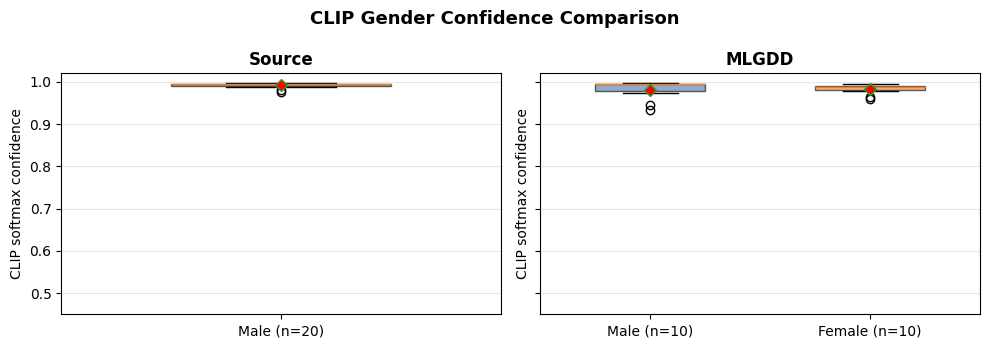

In [13]:
def plot_confidence_boxplot(
    results_a: list[dict],
    results_b: list[dict],
    label_a: str = 'Source',
    label_b: str = 'MLGDD',
) -> None:
    """Side-by-side boxplot of CLIP confidence for two scribble conditions."""
    def _split(results):
        m = [r['confidence'] for r in results if r['gender'] == 'Male']
        f = [r['confidence'] for r in results if r['gender'] == 'Female']
        return m, f

    m_a, f_a = _split(results_a)
    m_b, f_b = _split(results_b)

    fig, axes = plt.subplots(1, 2, figsize=(10, H), sharey=True)
    for ax, (m, f, label) in zip(axes, [(m_a, f_a, label_a), (m_b, f_b, label_b)]):
        data, labels = [], []
        if m: data.append(m); labels.append(f'Male (n={len(m)})')
        if f: data.append(f); labels.append(f'Female (n={len(f)})')
        if data:
            bp = ax.boxplot(
                data, tick_labels=labels, patch_artist=True,
                widths=0.5, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=6),
            )
            for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
                patch.set_facecolor(color)
                patch.set_alpha(0.6)
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.set_ylabel('CLIP softmax confidence')
        ax.set_ylim(0.45, 1.02)
        ax.grid(True, alpha=0.3, axis='y')
    fig.suptitle('CLIP Gender Confidence Comparison', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_confidence_boxplot(results_source, results_mlgdd, label_a='Source', label_b='MLGDD')

---
## 7. Gender Saliency Heatmap

Backpropagates the CLIP gender score through the differentiable pipeline
`scribble → Sprinter → VAE decode → CLIP` to identify which spatial regions
drive gender classification (mirrors `gender_saliency.py`).

Computing saliency for SOURCE scribble...


Saliency seeds:   0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_928/711733002.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


  seed 0: grad_sum=1645.692993, score=0.0543
  seed 1: grad_sum=4524.290527, score=0.0560
  seed 2: grad_sum=3957.042480, score=0.0561
  seed 3: grad_sum=3391.825439, score=0.0469
  seed 4: grad_sum=1520.129639, score=0.0565
  seed 5: grad_sum=2194.807129, score=0.0340
  seed 6: grad_sum=2834.256348, score=0.0503
  seed 7: grad_sum=3503.708008, score=0.0390
  seed 8: grad_sum=1586.346191, score=0.0542
  seed 9: grad_sum=2967.213623, score=0.0532
  seed 10: grad_sum=65139.191406, score=0.0536
  seed 11: grad_sum=1155.299927, score=0.0430
  seed 12: grad_sum=2010.023804, score=0.0502
  seed 13: grad_sum=1854.619873, score=0.0603
  seed 14: grad_sum=3912.559082, score=0.0561
  seed 15: grad_sum=3951.044189, score=0.0451
  seed 16: grad_sum=1897.055786, score=0.0510
  seed 17: grad_sum=1813.501099, score=0.0520
  seed 18: grad_sum=2657.122314, score=0.0469
  seed 19: grad_sum=6209.291016, score=0.0479


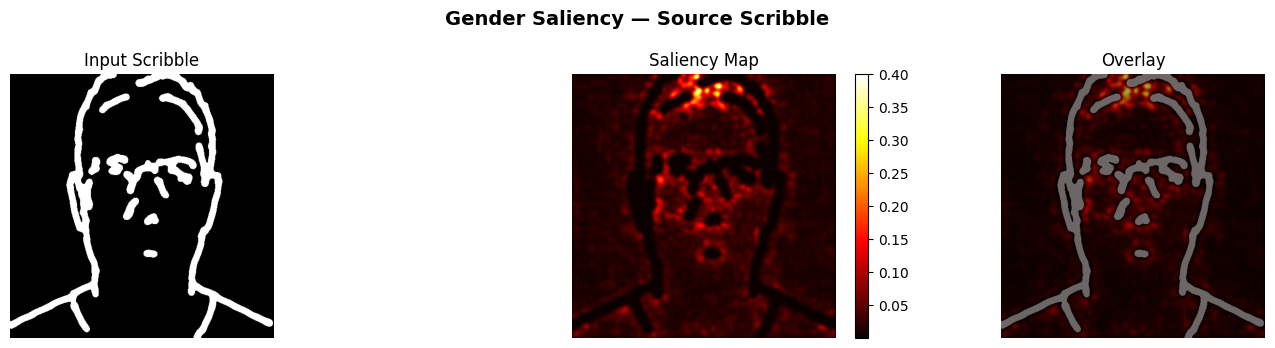

Computing saliency for MLGDD scribble...


Saliency seeds:   0%|          | 0/20 [00:00<?, ?it/s]

  seed 0: grad_sum=116.593185, score=0.0553
  seed 1: grad_sum=382.283691, score=-0.0326
  seed 2: grad_sum=102.507568, score=-0.0422
  seed 3: grad_sum=186.100723, score=-0.0441
  seed 4: grad_sum=215.151108, score=-0.0427
  seed 5: grad_sum=326.568481, score=0.0437
  seed 6: grad_sum=550.901367, score=0.0529
  seed 7: grad_sum=1781.354370, score=0.0309
  seed 8: grad_sum=622.756592, score=0.0615
  seed 9: grad_sum=154.005798, score=-0.0527
  seed 10: grad_sum=649.172974, score=0.0317
  seed 11: grad_sum=712.368652, score=0.0302
  seed 12: grad_sum=144.605896, score=-0.0533
  seed 13: grad_sum=135.760422, score=-0.0385
  seed 14: grad_sum=433.583832, score=-0.0428
  seed 15: grad_sum=165.410843, score=-0.0488
  seed 16: grad_sum=270.630066, score=0.0506
  seed 17: grad_sum=188.853882, score=0.0552
  seed 18: grad_sum=261.144562, score=-0.0338
  seed 19: grad_sum=2347.019043, score=0.0413


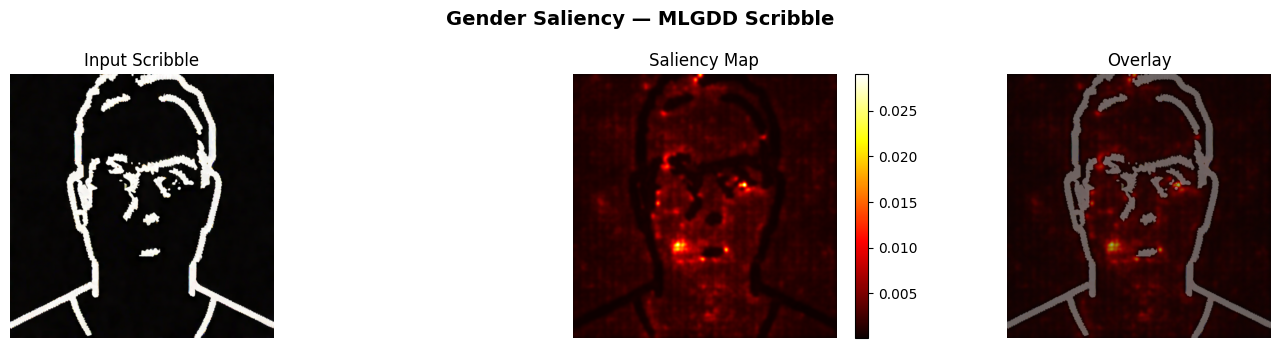

In [14]:
# ── Precompute gender text embeddings (male / female direction) ───────────────
_gender_proc   = CLIPProcessor.from_pretrained('openai/clip-vit-large-patch14')
_gender_inputs = _gender_proc(
    text=[MALE_PROMPT, FEMALE_PROMPT], return_tensors='pt', padding=True
).to(device)

with torch.no_grad():
    _g_out  = clip_model.get_text_features(**_gender_inputs)
    _g_embs = _g_out if isinstance(_g_out, torch.Tensor) else _g_out.pooler_output
    _g_embs = _g_embs / _g_embs.norm(dim=-1, keepdim=True)  # [2, 768]


def compute_saliency(
    scribble_np: np.ndarray,
    n_seeds: int = N_SEEDS,
    sigma: float = SIGMA,
) -> np.ndarray:
    """Accumulate gradient magnitude across seeds; return smoothed heatmap."""
    grad_accum = np.zeros((512, 512), dtype=np.float64)

    # Keep VAE in float32 so gradients flow
    vae.float()

    for seed in tqdm(range(n_seeds), desc='Saliency seeds'):
        torch.manual_seed(seed)
        if device == 'cuda':
            torch.cuda.manual_seed(seed)

        scribble_tensor = torch.tensor(
            scribble_np, device=device, dtype=torch.float32
        ).permute(2, 0, 1).unsqueeze(0)  # [1, 3, 512, 512]
        scribble_tensor.requires_grad_(True)

        def _forward(ctrl):
            var_latents = sprinter(
                prompt=[VARIATION_PROMPT],
                image=ctrl,
                num_inference_steps=2,
                guidance_scale=0.0,
                controlnet_conditioning_scale=CONTROLNET_SCALE,
                output_type='latent',
                return_dict=True,
            ).images
            var_pixels = vae.decode(
                var_latents.float() / vae_scaling_factor
            ).sample
            var_pixels = torch.clamp((var_pixels.float() + 1.0) / 2.0, 0.0, 1.0)
            with torch.cuda.amp.autocast(enabled=False):
                return encode_images_clip(var_pixels.float(), clip_model, clip_processor)

        img_emb = torch.utils.checkpoint.checkpoint(
            _forward, scribble_tensor, use_reentrant=False
        )  # [1, 768]

        # Male − female cosine similarity score
        score = (img_emb @ _g_embs[0]) - (img_emb @ _g_embs[1])
        score.backward()

        grad           = scribble_tensor.grad.detach()           # [1, 3, 512, 512]
        grad_magnitude = grad.abs().sum(dim=1).squeeze(0).cpu().numpy()
        print(f'  seed {seed}: grad_sum={grad_magnitude.sum():.6f}, score={score.item():.4f}')
        grad_accum += grad_magnitude.astype(np.float64)

    vae.half()  # restore

    grad_avg    = grad_accum / n_seeds
    grad_smooth = gaussian_filter(grad_avg, sigma=sigma)
    return grad_smooth


def plot_saliency(
    heatmap: np.ndarray,
    scribble_np: np.ndarray,
    title: str = 'Gender Saliency',
) -> None:
    """Three-panel: Input | Heatmap | Overlay."""
    fig, axes = plt.subplots(1, 3, figsize=(15, H))
    axes[0].imshow(scribble_np);               axes[0].set_title('Input Scribble'); axes[0].axis('off')
    im = axes[1].imshow(heatmap, cmap='hot');  axes[1].set_title('Saliency Map');   axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    axes[2].imshow(scribble_np)
    axes[2].imshow(heatmap, cmap='hot', alpha=0.6)
    axes[2].set_title('Overlay');              axes[2].axis('off')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


print('Computing saliency for SOURCE scribble...')
saliency_source = compute_saliency(src_np)
plot_saliency(saliency_source, src_np, title='Gender Saliency — Source Scribble')

print('Computing saliency for MLGDD scribble...')
saliency_mlgdd = compute_saliency(mlgd_np)
plot_saliency(saliency_mlgdd, mlgd_np, title='Gender Saliency — MLGDD Scribble')

### 7a. Saliency Lines & Correlation Plot

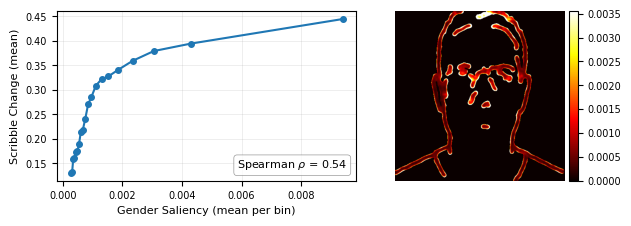

Spearman ρ = 0.5429 (p=0.0000)
Pearson  r = 0.2815  (p=0.0000)


In [15]:
def plot_saliency_lines_and_corr(
    saliency: np.ndarray,
    diff: np.ndarray,
    scribble_np: np.ndarray,
    n_bins: int = 20,
) -> None:
    """Correlation between gender saliency and scribble change, on stroke pixels."""
    line_mask = scribble_np.mean(axis=2) > 0.05
    sal_masked = np.zeros_like(saliency)
    sal_masked[line_mask] = saliency[line_mask]

    sal_lines  = saliency.flatten()[line_mask.flatten()]
    diff_lines = diff.flatten()[line_mask.flatten()]

    rho, p_spearman = spearmanr(sal_lines, diff_lines)
    r,   p_pearson  = pearsonr(sal_lines,  diff_lines)

    bins    = np.percentile(sal_lines, np.linspace(0, 100, n_bins + 1))
    bin_idx = np.clip(np.digitize(sal_lines, bins) - 1, 0, n_bins - 1)
    bin_sal  = [sal_lines[bin_idx == k].mean()  for k in range(n_bins)]
    bin_diff = [diff_lines[bin_idx == k].mean() for k in range(n_bins)]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(6.75, 2.2),
        gridspec_kw={'width_ratios': [1.6, 1], 'wspace': 0.15},
    )

    # Left: correlation plot
    axes[0].plot(bin_sal, bin_diff, 'o-', lw=1.5, ms=4)
    axes[0].set_xlabel('Gender Saliency (mean per bin)', fontsize=8)
    axes[0].set_ylabel('Scribble Change (mean)',         fontsize=8)
    axes[0].tick_params(labelsize=7)
    axes[0].grid(True, alpha=0.3, linewidth=0.5)
    axes[0].text(
        0.97, 0.05,
        f'Spearman $\\rho$ = {rho:.2f}',
        transform=axes[0].transAxes, ha='right', va='bottom', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8,
                  edgecolor='gray', linewidth=0.5),
    )

    # Right: masked saliency heatmap
    axes[1].imshow(np.zeros((*saliency.shape, 3), dtype=np.uint8))
    im = axes[1].imshow(
        sal_masked, cmap='hot', vmin=0,
        vmax=np.percentile(sal_masked[sal_masked > 0], 90),
    )
    axes[1].axis('off')
    divider = make_axes_locatable(axes[1])
    cax     = divider.append_axes('right', size='5%', pad=0.05)
    cb      = plt.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=7)

    plt.savefig('saliency_corr_figure.png', dpi=600, bbox_inches='tight')
    plt.show()
    print(f'Spearman ρ = {rho:.4f} (p={p_spearman:.4f})')
    print(f'Pearson  r = {r:.4f}  (p={p_pearson:.4f})')


plot_saliency_lines_and_corr(saliency_source, diff_smooth, src_np)

### 5b. Aggregate Added / Omitted Across All Runs (Google Drive)

Mounts Drive, loads all `(scribble.png, final_scribble_lgd_cm.png)` pairs from every
`dps_main_*` run, and averages the signed difference to reveal **systematically** added/removed regions.

In [ ]:
# # ── Mount Drive & configure ───────────────────────────────────────────────────
# import json
# from google.colab import drive
# drive.mount('/content/drive')

# RUNS_ROOT          = Path('/content/drive/MyDrive/conditional-matching/runs')
# SOURCE_FILENAME    = 'scribble.png'
# OPTIMIZED_FILENAME = 'final_scribble_lgd_cm.png'
# AGG_THRESHOLD      = 0.03
# AGG_SIGMA          = 2.0
# FILTER_SEED        = 1
# MAX_PAIRS          = 50

# # ── Debug: check the root exists and list top-level contents ──────────────────
# print(f'RUNS_ROOT exists: {RUNS_ROOT.exists()}')
# if RUNS_ROOT.exists():
#     children = list(RUNS_ROOT.iterdir())
#     print(f'Total children in runs/: {len(children)}')
#     for c in children[:10]:
#         print(f'  {c.name}')
#     if len(children) > 10:
#         print(f'  ... and {len(children)-10} more')
# else:
#     print('PATH NOT FOUND — check your Drive path above')

In [ ]:
# import json
# from collections import Counter

# FILTER_SEED = 1
# MAX_PAIRS   = 50

# print('Scanning runs (shallow, one level)...')
# all_pairs = []
# for run_dir in sorted(RUNS_ROOT.iterdir()):
#     if not run_dir.is_dir():
#         continue
#     src = run_dir / SOURCE_FILENAME
#     opt = run_dir / OPTIMIZED_FILENAME
#     if src.exists() and opt.exists():
#         all_pairs.append((src, opt))
# print(f'  Pairs with both files: {len(all_pairs)}')

# print(f'Filtering for seed == {FILTER_SEED}...')
# seed1_pairs, no_metrics, wrong_seed = [], 0, 0
# for src, opt in tqdm(all_pairs, desc='Checking metrics.json'):
#     metrics_path = src.parent / 'metrics.json'
#     if not metrics_path.exists():
#         no_metrics += 1
#         continue
#     try:
#         with open(metrics_path) as f:
#             seed = json.load(f).get('args', {}).get('seed')
#     except Exception:
#         no_metrics += 1
#         continue
#     if seed != FILTER_SEED:
#         wrong_seed += 1
#     else:
#         seed1_pairs.append((src, opt))
# print(f'  No metrics.json : {no_metrics}')
# print(f'  Wrong seed      : {wrong_seed}')
# print(f'  Seed == {FILTER_SEED}       : {len(seed1_pairs)}')

# # ── Find the most common source image ────────────────────────────────────────
# # Hash each source by its pixel content so we compare actual images, not paths
# print('Hashing source images to find most common...')
# from hashlib import md5
# def hash_image(path: Path) -> str:
#     with open(path, 'rb') as f:
#         return md5(f.read()).hexdigest()

# hash_counter = Counter()
# pair_by_hash = {}  # hash -> list of (src, opt)
# for src, opt in tqdm(seed1_pairs, desc='Hashing sources'):
#     h = hash_image(src)
#     hash_counter[h] += 1
#     pair_by_hash.setdefault(h, []).append((src, opt))

# most_common_hash, count = hash_counter.most_common(1)[0]
# print(f'\nMost common source: {count} runs share the same source image')
# print(f'  Example path: {pair_by_hash[most_common_hash][0][0]}')

# # ── Show top-5 sources for visibility ────────────────────────────────────────
# print('\nTop 5 source images by frequency:')
# for h, n in hash_counter.most_common(5):
#     print(f'  {n:3d} runs  →  {pair_by_hash[h][0][0].parent.name}  (hash={h[:8]})')

# pairs = pair_by_hash[most_common_hash][:MAX_PAIRS]
# print(f'\nUsing {len(pairs)} pairs with the most common source (capped at {MAX_PAIRS})')
# for i, (src, opt) in enumerate(pairs):
#     print(f'  [{i+1:02d}] {src.parent.name}')

In [ ]:
# # ── Accumulate signed difference across all runs ──────────────────────────────
# def load_as_float(path: Path, size: int = 512) -> np.ndarray:
#     img = Image.open(path).convert('RGB').resize((size, size), Image.LANCZOS)
#     return np.array(img).astype(np.float32) / 255.0

# accum_signed = np.zeros((512, 512), dtype=np.float64)
# accum_src    = np.zeros((512, 512, 3), dtype=np.float64)
# skipped      = 0

# for src_path, opt_path in tqdm(pairs, desc='Processing runs'):
#     try:
#         src_np = load_as_float(src_path)
#         opt_np = load_as_float(opt_path)
#     except Exception as e:
#         print(f'  Skipping {src_path.parent.name}: {e}')
#         skipped += 1
#         continue
#     accum_signed += (opt_np - src_np).mean(axis=2).astype(np.float64)
#     accum_src    += src_np.astype(np.float64)

# n_valid             = len(pairs) - skipped
# mean_signed         = (accum_signed / n_valid).astype(np.float32)
# mean_src_agg        = (accum_src    / n_valid).astype(np.float32)
# mean_signed_smooth  = gaussian_filter(mean_signed, sigma=AGG_SIGMA)

# print(f'Processed {n_valid} runs  ({skipped} skipped).')
# print(f'Signed diff range: [{mean_signed_smooth.min():.4f}, {mean_signed_smooth.max():.4f}]')

In [ ]:
# # ── Plot aggregate added / omitted ────────────────────────────────────────────
# changed_mask = np.abs(mean_signed_smooth) >= AGG_THRESHOLD
# added_mask   = changed_mask & (mean_signed_smooth > 0)
# removed_mask = changed_mask & (mean_signed_smooth < 0)

# grey    = mean_src_agg.mean(axis=2, keepdims=True).repeat(3, axis=2)
# overlay = grey.copy()

# add_mag  = np.where(added_mask,    mean_signed_smooth,  0.0)
# rem_mag  = np.where(removed_mask, -mean_signed_smooth,  0.0)
# add_norm = add_mag / (add_mag.max() + 1e-8)
# rem_norm = rem_mag / (rem_mag.max() + 1e-8)

# overlay[added_mask,   0] = 0.05
# overlay[added_mask,   1] = 0.4 + 0.6 * add_norm[added_mask]   # green
# overlay[added_mask,   2] = 0.05
# overlay[removed_mask, 0] = 0.4 + 0.6 * rem_norm[removed_mask] # red
# overlay[removed_mask, 1] = 0.05
# overlay[removed_mask, 2] = 0.05
# overlay = np.clip(overlay, 0.0, 1.0)

# vmax = np.abs(mean_signed_smooth).max()
# fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# axes[0].imshow(np.clip(mean_src_agg, 0, 1))
# axes[0].set_title('Mean Source Scribble', fontsize=9); axes[0].axis('off')

# im = axes[1].imshow(mean_signed_smooth, cmap='RdYlGn', vmin=-vmax, vmax=vmax)
# axes[1].set_title('Mean Signed Diff\n(green=added, red=removed)', fontsize=9); axes[1].axis('off')
# divider = make_axes_locatable(axes[1])
# plt.colorbar(im, cax=divider.append_axes('right', size='5%', pad=0.05)).ax.tick_params(labelsize=7)

# axes[2].imshow(overlay)
# axes[2].set_title(f'RGB Overlay  [threshold={AGG_THRESHOLD}]', fontsize=9); axes[2].axis('off')

# # Side-by-side: additions only | removals only
# add_only = grey.copy()
# add_only[added_mask, 0] = 0.05
# add_only[added_mask, 1] = 0.4 + 0.6 * add_norm[added_mask]
# add_only[added_mask, 2] = 0.05
# rem_only = grey.copy()
# rem_only[removed_mask, 0] = 0.4 + 0.6 * rem_norm[removed_mask]
# rem_only[removed_mask, 1] = 0.05
# rem_only[removed_mask, 2] = 0.05
# axes[3].imshow(np.concatenate([np.clip(add_only, 0,1), np.clip(rem_only, 0,1)], axis=1))
# axes[3].axvline(x=511.5, color='white', lw=0.8, linestyle='--')
# axes[3].set_title('Added only  |  Removed only', fontsize=9); axes[3].axis('off')

# fig.suptitle(f'Aggregate MLGD-D Scribble Edits  (n={n_valid} runs)',
#              fontsize=12, fontweight='bold')
# plt.tight_layout()
# plt.savefig('aggregate_added_omitted.png', dpi=300, bbox_inches='tight')
# plt.show()

# total = changed_mask.size
# print(f'Unchanged : {total - changed_mask.sum():,}  ({100*(total-changed_mask.sum())/total:.1f}%)')
# print(f'Added     : {added_mask.sum():,}  ({100*added_mask.sum()/total:.1f}%)')
# print(f'Removed   : {removed_mask.sum():,}  ({100*removed_mask.sum()/total:.1f}%)')

### 7b. Save Results

In [ ]:
save_dict = {
    'saliency_source': saliency_source,
    'saliency_mlgdd':  saliency_mlgdd,
    'diff_smooth':     diff_smooth,
    'src_np':          src_np,
    'mlgd_np':         mlgd_np,
}

with open('saliency_results.pkl', 'wb') as f:
    pickle.dump(save_dict, f)

print('Saved saliency_results.pkl')